# Тестовое задание: классификация и граф контрагентов

**Выбранная ветка:** A — Data / ML.

Ноутбук покрывает обязательную базовую часть: EDA, очистку, SQL-запросы, а также Data/ML-ветку: keyword baseline, TF-IDF + Logistic Regression, per-class метрики, confusion matrix, confidence-score и threshold для ручной проверки.

## 0. Импорты и пути

Перед запуском положите входные файлы в папку `data/`: `transactions.csv`, `categories.json`, `gold_set.csv`.

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent

import sys
sys.path.append(str(ROOT / 'src'))

from cleaning import load_transactions, clean_transactions
from classification import (
    load_categories, keyword_predict, make_weak_training_data, build_ml_model,
    predict_with_confidence, evaluate_predictions, top_confusions
)

DATA_DIR = ROOT / 'data'
SQL_DIR = ROOT / 'sql'
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

TRANSACTIONS_PATH = DATA_DIR / 'transactions.csv'
CATEGORIES_PATH = DATA_DIR / 'categories.json'
GOLD_PATH = DATA_DIR / 'gold_set.csv'

for path in [TRANSACTIONS_PATH, CATEGORIES_PATH, GOLD_PATH]:
    assert path.exists(), f'Не найден файл: {path}'

## 1.1. EDA

In [2]:
df_raw = load_transactions(TRANSACTIONS_PATH)
df_raw.head()

,sender_id,receiver_id,date,amount_kzt,description,doc_type
0,341113577953,421128527724,2024-10-05,18579.93,"Поставка канцелярских товаров (бумага А4, ручк...",INVOICE
1,950908633188,821120551797,2025-07-29,1706226.33,Поставка медикаментов по списку,INVOICE
2,500817613929,830425668259,2025/05/17,286266.87,"СИЗ: перчатки, очки, респираторы",INVOICE
3,110824699080,220312376061,2024-02-08,996569.04,Грузоперевозка щебня по г. Алматы,INVOICE
4,910816595223,110910187697,20/10/2024,120351.41,ГСМ за февраль 2025,INVOICE


In [3]:
rows, cols = df_raw.shape
parsed_dates = pd.to_datetime(df_raw['date'], errors='coerce', dayfirst=True, format='mixed')
unique_counterparties = pd.concat([df_raw['sender_id'], df_raw['receiver_id']]).nunique()

eda_summary = pd.DataFrame([{
    'rows': rows,
    'columns': cols,
    'period_start': parsed_dates.min().date(),
    'period_end': parsed_dates.max().date(),
    'unique_counterparties_raw': unique_counterparties,
    'duplicate_rows_full': int(df_raw.duplicated().sum()),
    'missing_description_share': round(float(df_raw['description'].isna().mean()), 4),
}])
eda_summary

,rows,columns,period_start,period_end,unique_counterparties_raw,duplicate_rows_full,missing_description_share
0,80800,6,2024-01-01,2026-04-30,7215,800,0.0105


In [4]:
outgoing_top20 = (
    df_raw.groupby('sender_id', dropna=False)['amount_kzt']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name='outgoing_turnover_kzt')
)
outgoing_top20

,sender_id,outgoing_turnover_kzt
0,720221554469,7.554451e+08
1,580811600403,7.445998e+08
2,310909691346,7.187724e+08
3,170915651329,7.069924e+08
4,181226594058,7.033694e+08
5,140512557513,6.866489e+08
6,401110643824,6.791805e+08
7,570328465547,6.405617e+08
8,941101594315,6.364129e+08
9,460614400792,6.136171e+08


In [5]:
incoming_top20 = (
    df_raw.groupby('receiver_id', dropna=False)['amount_kzt']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name='incoming_turnover_kzt')
)
incoming_top20

,receiver_id,incoming_turnover_kzt
0,850603506938,3.733961e+08
1,711020691210,3.494212e+08
2,551211641020,3.460529e+08
3,410517502025,3.351119e+08
4,730424495604,3.230030e+08
5,121125400846,3.086955e+08
6,850623490114,3.056108e+08
7,731211426100,2.842297e+08
8,990508519961,2.741360e+08
9,861228440096,2.610135e+08


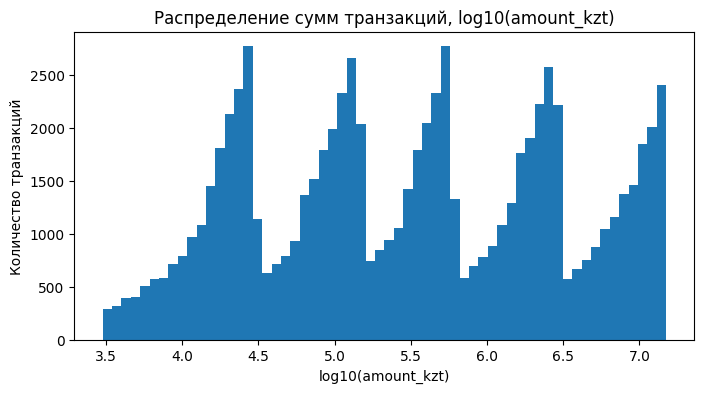

In [6]:
positive_amounts = df_raw.loc[df_raw['amount_kzt'] > 0, 'amount_kzt']
plt.figure(figsize=(8, 4))
plt.hist(np.log10(positive_amounts), bins=60)
plt.title('Распределение сумм транзакций, log10(amount_kzt)')
plt.xlabel('log10(amount_kzt)')
plt.ylabel('Количество транзакций')
plt.show()

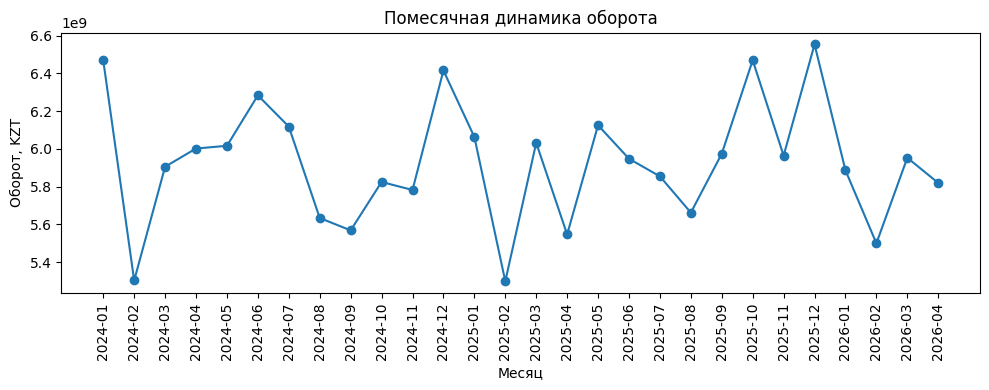

,month,turnover_kzt
23,2025-12,6.553572e+09
24,2026-01,5.885963e+09
25,2026-02,5.499337e+09
26,2026-03,5.952787e+09
27,2026-04,5.819337e+09


In [7]:
monthly_dynamics = (
    df_raw.assign(date_parsed=parsed_dates)
    .dropna(subset=['date_parsed'])
    .assign(month=lambda x: x['date_parsed'].dt.to_period('M').astype(str))
    .groupby('month')['amount_kzt']
    .sum()
    .reset_index(name='turnover_kzt')
)

plt.figure(figsize=(10, 4))
plt.plot(monthly_dynamics['month'], monthly_dynamics['turnover_kzt'], marker='o')
plt.title('Помесячная динамика оборота')
plt.xlabel('Месяц')
plt.ylabel('Оборот, KZT')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

monthly_dynamics.tail()

### Наблюдаемые аномалии

В этом блоке фиксируются минимум 3 аномалии: невалидные идентификаторы, дубли, пустые описания, суммы `<= 0`, а также экстремально большие суммы.

In [8]:
from cleaning import is_valid_iin_bin

anomalies = pd.DataFrame([
    {'anomaly': 'sender_id не прошёл контрольную сумму БИН/ИИН', 'count': int((~df_raw['sender_id'].map(is_valid_iin_bin)).sum())},
    {'anomaly': 'receiver_id не прошёл контрольную сумму БИН/ИИН', 'count': int((~df_raw['receiver_id'].map(is_valid_iin_bin)).sum())},
    {'anomaly': 'полные дубликаты строк', 'count': int(df_raw.duplicated().sum())},
    {'anomaly': 'пустое description', 'count': int(df_raw['description'].isna().sum())},
    {'anomaly': 'amount_kzt <= 0', 'count': int((df_raw['amount_kzt'] <= 0).sum())},
    {'anomaly': 'amount_kzt выше 99.9 перцентиля', 'count': int((df_raw['amount_kzt'] > df_raw['amount_kzt'].quantile(0.999)).sum())},
])
anomalies

,anomaly,count
0,sender_id не прошёл контрольную сумму БИН/ИИН,1190
1,receiver_id не прошёл контрольную сумму БИН/ИИН,1126
2,полные дубликаты строк,800
3,пустое description,847
4,amount_kzt <= 0,384
5,amount_kzt выше 99.9 перцентиля,81


## 1.2. Очистка данных

Правило дедупликации: удаляются повторные записи с одинаковыми `sender_id`, `receiver_id`, нормализованной датой, суммой, описанием и типом документа. Такой ключ трактуется как повторная выгрузка одной и той же операции.

In [9]:
df_clean, quality_table = clean_transactions(df_raw)
quality_table

,stage,rows,sender_id_valid_share,receiver_id_valid_share,both_ids_valid_share,missing_values_share,missing_description_share
0,before,80800,0.9853,0.9861,0.9713,0.0013,0.0105
1,after,80000,0.9853,0.9860,0.9713,0.0012,0.0104


In [10]:
clean_summary = pd.DataFrame([{
    'rows_before': len(df_raw),
    'rows_after': len(df_clean),
    'removed_duplicates_by_business_key': len(df_raw) - len(df_clean),
    'period_start_clean': pd.to_datetime(df_clean['date_iso']).min().date(),
    'period_end_clean': pd.to_datetime(df_clean['date_iso']).max().date(),
    'unique_counterparties_clean': pd.concat([df_clean['sender_id'], df_clean['receiver_id']]).nunique(),
}])
clean_summary

,rows_before,rows_after,removed_duplicates_by_business_key,period_start_clean,period_end_clean,unique_counterparties_clean
0,80800,80000,800,2024-01-01,2026-04-30,7215


## 1.3. SQL-часть

In [11]:
conn = sqlite3.connect(':memory:')
df_clean.to_sql('transactions_clean', conn, index=False, if_exists='replace')

def run_sql_file(filename: str) -> pd.DataFrame:
    query = (SQL_DIR / filename).read_text(encoding='utf-8')
    return pd.read_sql_query(query, conn)

In [12]:
# Топ-10 пар контрагентов по сумме оборота
top_pairs = run_sql_file('01_top_pairs.sql')
top_pairs

,sender_id,receiver_id,operations_count,turnover_kzt
0,960819662090,711020691210,106,2.975443e+08
1,271023534832,850603506938,94,2.564739e+08
2,310405616795,551211641020,105,2.452937e+08
3,640522553440,730424495604,88,2.368354e+08
4,151008697404,740201661314,90,2.296884e+08
5,550624571494,850623490114,82,2.294590e+08
6,760616418322,410517502025,79,2.125045e+08
7,861121409930,121125400846,87,2.042040e+08
8,680213490446,900326509443,88,2.020552e+08
9,960406579569,221201693852,89,1.864100e+08


In [13]:
# Месячный rolling-sum оборота по каждому отправителю, 3-месячное окно
rolling_sender = run_sql_file('02_monthly_rolling_sender.sql')
rolling_sender.head(20)

,sender_id,month,monthly_turnover_kzt,rolling_3m_turnover_kzt
0,000 424074882,2024-08,869214.84,869214.84
1,000103385227,2024-03,55257.61,55257.61
2,000103385227,2024-09,144124.44,199382.05
3,000103385227,2024-11,23653.16,223035.21
4,000103385227,2025-01,10440.91,178218.51
5,000103385227,2025-03,2745540.03,2779634.10
6,000103385227,2025-08,68892.16,2824873.10
7,000103385227,2025-12,4008535.20,6822967.39
8,000103385227,2026-02,618046.75,4695474.11
9,000106-497273,2026-01,140243.35,140243.35


In [14]:
# Контрагенты, у которых >70% входящих платежей приходит от одного источника
concentrated_incoming = run_sql_file('03_concentrated_incoming.sql')
concentrated_incoming.head(20)

,receiver_id,dominant_source_id,dominant_source_incoming_kzt,total_incoming_kzt,dominant_source_share
0,670603-689146,030324567457,15273097.72,15273097.72,1.0
1,39080265977I,421016575804,14967308.40,14967308.40,1.0
2,59I208463504,680817441858,14901145.43,14901145.43,1.0
3,580623-401932,910110516176,14854209.43,14854209.43,1.0
4,74080252374,240418522967,14821360.73,14821360.73,1.0
5,21042859722,920210252426,14810134.70,14810134.70,1.0
6,34O708633232,861218496740,14661374.72,14661374.72,1.0
7,050306 433104,390121605700,14556383.27,14556383.27,1.0
8,0303I2412943,460614400792,14485507.72,14485507.72,1.0
9,6810055 13699,540101435822,14457394.21,14457394.21,1.0


## 2. Ветка A — Data / ML

Задача: классифицировать `description` в одну из 20 категорий из `categories.json`. Реализованы два подхода:

1. `keyword/regex baseline` по словарю ключевых слов.
2. `TF-IDF + Logistic Regression` на слабой разметке, сгенерированной из названий категорий и ключевых слов.

In [15]:
categories = load_categories(CATEGORIES_PATH)
labels = list(categories.keys())
gold = pd.read_csv(GOLD_PATH, dtype={'description': 'string', 'category_code': 'string', 'category_name': 'string'})
gold.head()

,description,category_code,category_name
0,"Доставка груза 5 тонн, маршрут Шымкент-Тараз",49.41,Услуги перевозки грузов автотранспортом
1,Дизельное топливо 5000 л,19.20,Топливо и ГСМ
2,"Офисная мебель: столы, стулья — 15 рабочих мест",31.01,Мебель и офисное оборудование
3,Услуги: лекарственные препараты по заявке №21,21.20,Медицинские товары и препараты
4,хлебобулочные изделия — партия №14,10.71,Продукты питания (опт)


### 2.1. Keyword / regex baseline

In [16]:
kw_pred = keyword_predict(gold['description'], categories)
kw_eval = pd.concat([gold, kw_pred], axis=1)
kw_report, kw_cm = evaluate_predictions(kw_eval['category_code'], kw_eval['pred_keyword'], labels)
kw_report.loc[labels, ['precision', 'recall', 'f1-score', 'support']]

,precision,recall,f1-score,support
49.41,1.000000,1.0,1.000000,10.0
17.23,1.000000,1.0,1.000000,10.0
62.01,1.000000,0.7,0.823529,10.0
68.20,1.000000,1.0,1.000000,10.0
35.30,1.000000,0.5,0.666667,10.0
69.10,1.000000,0.7,0.823529,10.0
69.20,0.625000,0.5,0.555556,10.0
23.61,1.000000,1.0,1.000000,10.0
10.71,1.000000,0.8,0.888889,10.0
19.20,1.000000,1.0,1.000000,10.0


In [17]:
kw_report.loc[['macro avg', 'weighted avg'], ['precision', 'recall', 'f1-score', 'support']]

,precision,recall,f1-score,support
macro avg,0.95625,0.895,0.915176,200.0
weighted avg,0.95625,0.895,0.915176,200.0


### 2.2. ML-классификатор: TF-IDF + Logistic Regression

In [18]:
train_weak = make_weak_training_data(categories)
model = build_ml_model()
model.fit(train_weak['text'], train_weak['category_code'])

ml_pred = predict_with_confidence(model, gold['description'], labels)
ml_eval = pd.concat([gold, ml_pred], axis=1)
ml_report, ml_cm = evaluate_predictions(ml_eval['category_code'], ml_eval['pred_ml'], labels)
ml_report.loc[labels, ['precision', 'recall', 'f1-score', 'support']]

,precision,recall,f1-score,support
49.41,1.000000,1.0,1.000000,10.0
17.23,1.000000,1.0,1.000000,10.0
62.01,1.000000,0.7,0.823529,10.0
68.20,1.000000,1.0,1.000000,10.0
35.30,0.769231,1.0,0.869565,10.0
69.10,0.636364,0.7,0.666667,10.0
69.20,0.625000,0.5,0.555556,10.0
23.61,0.666667,1.0,0.800000,10.0
10.71,1.000000,1.0,1.000000,10.0
19.20,1.000000,1.0,1.000000,10.0


In [19]:
comparison = pd.DataFrame({
    'keyword_macro_f1': [kw_report.loc['macro avg', 'f1-score']],
    'ml_macro_f1': [ml_report.loc['macro avg', 'f1-score']],
    'keyword_weighted_f1': [kw_report.loc['weighted avg', 'f1-score']],
    'ml_weighted_f1': [ml_report.loc['weighted avg', 'f1-score']],
}).round(4)
comparison

,keyword_macro_f1,ml_macro_f1,keyword_weighted_f1,ml_weighted_f1
0,0.9152,0.8829,0.9152,0.8829


In [20]:
ml_cm

,49.41,17.23,62.01,68.20,35.30,69.10,69.20,23.61,10.71,19.20,21.20,85.42,73.11,70.22,14.12,31.01,61.10,64.19,29.10,01.11
49.41,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
17.23,0,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
62.01,0,0,7,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0
68.20,0,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
35.30,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
69.10,0,0,0,0,0,7,0,0,0,0,0,0,0,3,0,0,0,0,0,0
69.20,0,0,0,0,3,0,5,0,0,0,0,0,0,2,0,0,0,0,0,0
23.61,0,0,0,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0
10.71,0,0,0,0,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0,0
19.20,0,0,0,0,0,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0


In [21]:
confusions = top_confusions(ml_cm, n=10)
confusions['true_name'] = confusions['true_code'].map(lambda c: categories[c]['name'])
confusions['pred_name'] = confusions['pred_code'].map(lambda c: categories[c]['name'])
confusions

,true_code,pred_code,count,true_name,pred_name
5,14.12,23.61,5,Спецодежда и СИЗ,Строительные материалы
4,70.22,69.10,4,Консалтинговые услуги,Юридические услуги
0,62.01,69.20,3,Разработка ПО и IT-услуги,Бухгалтерские и аудиторские услуги
2,69.20,35.30,3,Бухгалтерские и аудиторские услуги,"Коммунальные услуги (электро, газ, тепло)"
1,69.10,70.22,3,Юридические услуги,Консалтинговые услуги
3,69.20,70.22,2,Бухгалтерские и аудиторские услуги,Консалтинговые услуги
6,14.12,21.20,2,Спецодежда и СИЗ,Медицинские товары и препараты


### 2.3. Confidence-score и ручная проверка

Для ML-предсказания confidence-score — максимальная вероятность класса. Практический threshold: `confidence_ml < 0.45` отправляется на ручную проверку. Если нужна более высокая точность, threshold можно поднять до `0.55–0.60`, но тогда ручной очереди станет больше.

In [22]:
THRESHOLD = 0.45
manual_review = ml_eval[ml_eval['confidence_ml'] < THRESHOLD].copy()
manual_review_share = len(manual_review) / len(ml_eval)

pd.DataFrame([{
    'threshold': THRESHOLD,
    'manual_review_count_on_gold': len(manual_review),
    'manual_review_share_on_gold': round(manual_review_share, 4),
    'accuracy_above_threshold': round(float((ml_eval.loc[ml_eval['confidence_ml'] >= THRESHOLD, 'category_code'] == ml_eval.loc[ml_eval['confidence_ml'] >= THRESHOLD, 'pred_ml']).mean()), 4),
}])

,threshold,manual_review_count_on_gold,manual_review_share_on_gold,accuracy_above_threshold
0,0.45,43,0.215,0.9554


In [23]:
ml_eval[['description', 'category_code', 'pred_ml', 'confidence_ml']].head(20)

,description,category_code,pred_ml,confidence_ml
0,"Доставка груза 5 тонн, маршрут Шымкент-Тараз",49.41,49.41,0.539057
1,Дизельное топливо 5000 л,19.20,19.20,0.654334
2,"Офисная мебель: столы, стулья — 15 рабочих мест",31.01,31.01,0.645670
3,Услуги: лекарственные препараты по заявке №21,21.20,21.20,0.665506
4,хлебобулочные изделия — партия №14,10.71,10.71,0.507193
5,Ячмень фуражный — 50 тонн,01.11,01.11,0.568702
6,Дизельное топливо 5000 л,19.20,19.20,0.654334
7,Услуги: шкафы для документов 2-секционные,31.01,31.01,0.447595
8,"Медицинские маски — 5000 шт, количество 12",21.20,21.20,0.611408
9,"Цемент М400, 20 тонн по договору №196",23.61,23.61,0.595714


### 2.4. Классификация очищенных транзакций

In [24]:
transaction_predictions = predict_with_confidence(model, df_clean['description'].fillna(''), labels)
df_classified = pd.concat([df_clean, transaction_predictions], axis=1)
df_classified['needs_manual_review'] = df_classified['confidence_ml'] < THRESHOLD

category_distribution = (
    df_classified['pred_ml']
    .value_counts()
    .rename_axis('category_code')
    .reset_index(name='transactions_count')
)
category_distribution['category_name'] = category_distribution['category_code'].map(lambda c: categories[c]['name'])
category_distribution.head(20)

,category_code,transactions_count,category_name
0,49.41,9242,Услуги перевозки грузов автотранспортом
1,17.23,8978,Бумажные канцелярские принадлежности
2,23.61,6875,Строительные материалы
3,62.01,4746,Разработка ПО и IT-услуги
4,10.71,3947,Продукты питания (опт)
5,35.30,3814,"Коммунальные услуги (электро, газ, тепло)"
6,70.22,3798,Консалтинговые услуги
7,21.20,3783,Медицинские товары и препараты
8,69.10,3125,Юридические услуги
9,31.01,3101,Мебель и офисное оборудование


## 3. Итоговые выводы

In [26]:
findings = [
    f'Исходный файл: {len(df_raw):,} строк; после дедупликации: {len(df_clean):,} строк.'.replace(',', ' '),
    f'Период данных: {pd.to_datetime(df_clean["date_iso"]).min().date()} — {pd.to_datetime(df_clean["date_iso"]).max().date()}.',
    f'Уникальных контрагентов после очистки: {pd.concat([df_clean["sender_id"], df_clean["receiver_id"]]).nunique():,}.'.replace(',', ' '),
    f'Доля строк, где оба идентификатора прошли контрольную сумму: {quality_table.loc[quality_table.stage == "after", "both_ids_valid_share"].iloc[0]:.2%}.',
    f'Удалено дублей по бизнес-ключу: {len(df_raw) - len(df_clean):,}.'.replace(',', ' '),
    f'Keyword baseline macro-F1: {kw_report.loc["macro avg", "f1-score"]:.3f}.',
    f'ML TF-IDF + LogReg macro-F1: {ml_report.loc["macro avg", "f1-score"]:.3f}.',
    f'Разница между baseline и ML составляет {(kw_report.loc["macro avg", "f1-score"] - ml_report.loc["macro avg", "f1-score"]):.3f}.',
    f'На ручную проверку при threshold {THRESHOLD} уходит {manual_review_share:.1%} gold-примеров.',
    f'Доля пропусков в description после очистки: {quality_table.loc[quality_table.stage == "after", "missing_description_share"].iloc[0]:.2%}.'
]

for item in findings:
    print('-', item)

- Исходный файл: 80 800 строк; после дедупликации: 80 000 строк.
- Период данных: 2024-01-01 — 2026-04-30.
- Уникальных контрагентов после очистки: 7 215.
- Доля строк, где оба идентификатора прошли контрольную сумму: 97.13%.
- Удалено дублей по бизнес-ключу: 800.
- Keyword baseline macro-F1: 0.915.
- ML TF-IDF + LogReg macro-F1: 0.883.
- Разница между baseline и ML составляет 0.032.
- На ручную проверку при threshold 0.45 уходит 21.5% gold-примеров.
- Доля пропусков в description после очистки: 1.04%.
